# Results and visualisations for Chapter 3 Section: Data Extraction


In [10]:
from core.matlab_data_loader import MatlabDataLoader
import kineticstoolkit as ktk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
loader = MatlabDataLoader()

In [12]:
successful_sessions = loader.get_successful_sessions()
print(f"Number of successful sessions: {len(successful_sessions)}")

sessions_with_running_data = loader.get_discrete_variables()
print(f"Number of sessions with running data: {len(sessions_with_running_data)}")

Number of successful sessions: 2487
Number of sessions with running data: 1813


In [13]:
first_session_id = loader.get_successful_sessions()[0]
print("First session id: ", first_session_id)

L_KNEE_MARKER = "L_shank_1"
L_KNEE_JOINT = "L_knee"

# Raw
l_shank_1_marker_data = loader.get_marker_data(first_session_id, L_KNEE_MARKER)
l_knee_angle_data = loader.get_joint_angles(first_session_id, L_KNEE_JOINT, normalized=False)
l_knee_velocity_data = loader.get_joint_velocities(first_session_id, L_KNEE_JOINT, normalized=False)

# Normalised
l_knee_normalized_angle_data = loader.get_joint_angles(first_session_id, L_KNEE_JOINT, normalized=True)
l_knee_normalized_velocity_data = loader.get_joint_velocities(first_session_id, L_KNEE_JOINT, normalized=True)

First session id:  100001_20110531T161051


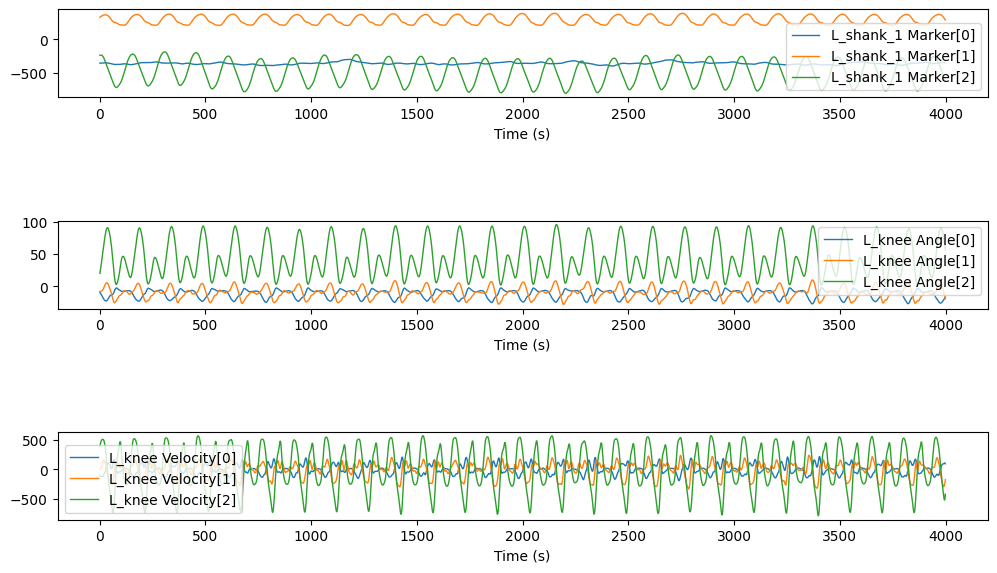

In [14]:
ts = ktk.TimeSeries()

ts.time = l_shank_1_marker_data['TimeIndex'][:3999]  # velocity has 1 frame less.
ts.units = "frames"

# Raw
ts = ts.add_data("L_shank_1 Marker", l_shank_1_marker_data.values[:3999,1:])
ts = ts.add_data("L_knee Angle", l_knee_angle_data.values[:3999,1:])
ts = ts.add_data("L_knee Velocity", l_knee_velocity_data.values[:3999,1:])

plt.figure(figsize=(12, 8))
plt.subplot(6, 1, 1)
ts.plot("L_shank_1 Marker")
plt.subplot(6, 1, 3)
ts.plot("L_knee Angle")
plt.subplot(6, 1, 5)
ts.plot("L_knee Velocity")
plt.show()

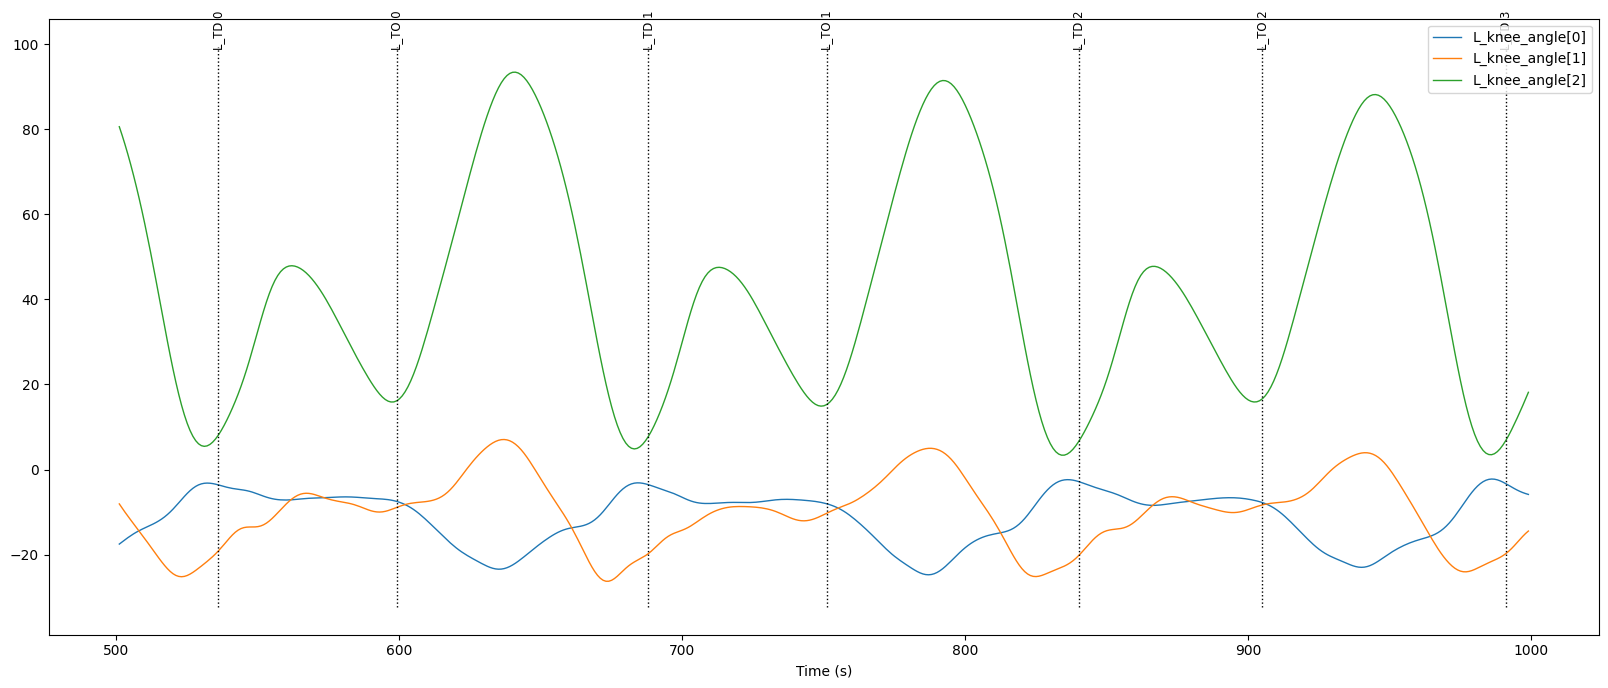

In [20]:
ts = loader.get_joint_angles_timeseries(first_session_id, "L_knee", normalized=False, include_events=True)

ts = ts.get_ts_after_time(500)
ts = ts.get_ts_before_time(1000)
ts = ts.trim_events()

plt.figure(figsize=(20, 8))
ts.plot()

## Data Validation

In [21]:
discrete_data = loader.get_discrete_variables()
display(discrete_data.info(verbose=True))

session_data = loader.get_session_data_full_cleaned()
display(session_data.info(verbose=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1813 entries, 0 to 1812
Data columns (total 84 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ID                              1813 non-null   object 
 1   Speed_Output                    1813 non-null   float64
 2   Label                           1813 non-null   object 
 3   Hz                              1813 non-null   int64  
 4   Step_Width_Left                 1813 non-null   float64
 5   Step_Width_Right                1813 non-null   float64
 6   Stride_Rate_Left                1813 non-null   float64
 7   Stride_Rate_Right               1813 non-null   float64
 8   Stride_Length_Left              1813 non-null   float64
 9   Stride_Length_Right             1813 non-null   float64
 10  Swing_Time_Left                 1813 non-null   float64
 11  Swing_Time_Right                1813 non-null   float64
 12  Stance_Time_Left                18

None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1832 entries, 0 to 1831
Data columns (total 114 columns):
 #    Column                       Dtype  
---   ------                       -----  
 0    id                           object 
 1    sub_id                       int64  
 2    datestring                   object 
 3    filename                     object 
 4    speed_r                      float64
 5    age                          float64
 6    Height                       float64
 7    Weight                       float64
 8    Gender                       object 
 9    DominantLeg                  object 
 10   Activities                   object 
 11   Level                        object 
 12   YrsRunning                   float64
 13   RaceDistance                 object 
 14   RaceTimeHrs                  float64
 15   RaceTimeMins                 float64
 16   RaceTimeSecs                 float64
 17   YrPR                         float64
 18   NumRaces                  

None

In [22]:
# Compare raw discrete variables vs session metadata
d_raw = loader.get_discrete_variables()
s_raw = loader.get_session_data_full_cleaned()

In [23]:
# Manual mapping: discrete_variables.csv -> session_data_full_cleaned.csv
DISCRETE_TO_SESSION_COLUMN_MAP = {
    # identifiers / speed
    "Speed_Output": "speed_r",
    "ID": "id",
    # left side
    "Step_Width_Left": "l_step_width",
    "Stride_Rate_Left": "l_stride_rate",
    "Stride_Length_Left": "l_stride_length",
    "Swing_Time_Left": "l_swing_time",
    "Stance_Time_Left": "l_stance_time",
    "Pelvis_Peak_Drop_Angle_Left": "l_pelvis_peak_drop_angle",
    "Pelvis_Drop_Excursion_Left": "l_pelvis_drop_excursion",
    "Ankle_DF_Peak_Angle_Left": "l_ankle_df_peak_angle",
    "Ankle_Eve_Peak_Angle_Left": "l_ankle_eve_peak_angle",
    "Ankle_Eve_Percent_Stance_Left": "l_ankle_eve_percent_stance",
    "Ankle_Eve_Excursion_Left": "l_ankle_eve_excursion",
    "Ankle_Rot_Peak_Angle_Left": "l_ankle_rot_peak_angle",
    "Ankle_Rot_Excursion_Left": "l_ankle_rot_excursion",
    "Knee_Flex_Peak_Angle_Left": "l_knee_flex_peak_angle",
    "Knee_Add_Peak_Angle_Left": "l_knee_add_peak_angle",
    "Knee_Add_Excursion_Left": "l_knee_add_excursion",
    "Knee_Abd_Peak_Angle_Left": "l_knee_abd_peak_angle",
    "Knee_Abd_Excursion_Left": "l_knee_abd_excursion",
    "Knee_Rot_Peak_Angle_Left": "l_knee_rot_peak_angle",
    "Knee_Rot_Excursion_Left": "l_knee_rot_excursion",
    "Hip_Ext_Peak_Angle_Left": "l_hip_ext_peak_angle",
    "Hip_Add_Peak_Angle_Left": "l_hip_add_peak_angle",
    "Hip_Add_Excursion_Left": "l_hip_add_excursion",
    "Hip_Rot_Peak_Angle_Left": "l_hip_rot_peak_angle",
    "Hip_Rot_Excursion_Left": "l_hip_rot_excursion",
    "Foot_Prog_Angle_Left": "l_foot_prog_angle",
    "Foot_Ang_At_HS_Left": "l_foot_ang_at_hs",
    "MHW_Exc_From_TO_Left": "l_mhw_exc_from_to",
    "Ankle_Eve_Peak_Vel_Left": "l_ankle_eve_peak_vel",
    "Ankle_Rot_Peak_Vel_Left": "l_ankle_rot_peak_vel",
    "Knee_Abd_Peak_Vel_Left": "l_knee_abd_peak_vel",
    "Knee_Add_Peak_Vel_Left": "l_knee_add_peak_vel",
    "Hip_Abd_Peak_Vel_Left": "l_hip_abd_peak_vel",
    "Knee_Rot_Peak_Vel_Left": "l_knee_rot_peak_vel",
    "Hip_Rot_Peak_Vel_Left": "l_hip_rot_peak_vel",
    "Pronation_Onset_Left": "l_pronation_onset",
    "Supination_Timing_Left": "l_pronation_offset",
    "Hip_Add_Peak_Vel_Left": "l_peak_hip_add_velocity",
    "Pelvic_Drop_Peak_Vel_Left": "l_peak_pelvic_drop_velocity",
    "Vertical_Oscillation_Left": "l_vertical_oscillation",

    # right side
    "Step_Width_Right": "r_step_width",
    "Stride_Rate_Right": "r_stride_rate",
    "Stride_Length_Right": "r_stride_length",
    "Swing_Time_Right": "r_swing_time",
    "Stance_Time_Right": "r_stance_time",
    "Pelvis_Peak_Drop_Angle_Right": "r_pelvis_peak_drop_angle",
    "Pelvis_Drop_Excursion_Right": "r_pelvis_drop_excursion",
    "Ankle_DF_Peak_Angle_Right": "r_ankle_df_peak_angle",
    "Ankle_Eve_Peak_Angle_Right": "r_ankle_eve_peak_angle",
    "Ankle_Eve_Percent_Stance_Right": "r_ankle_eve_percent_stance",
    "Ankle_Eve_Excursion_Right": "r_ankle_eve_excursion",
    "Ankle_Rot_Peak_Angle_Right": "r_ankle_rot_peak_angle",
    "Ankle_Rot_Excursion_Right": "r_ankle_rot_excursion",
    "Knee_Flex_Peak_Angle_Right": "r_knee_flex_peak_angle",
    "Knee_Add_Peak_Angle_Right": "r_knee_add_peak_angle",
    "Knee_Add_Excursion_Right": "r_knee_add_excursion",
    "Knee_Abd_Peak_Angle_Right": "r_knee_abd_peak_angle",
    "Knee_Abd_Excursion_Right": "r_knee_abd_excursion",
    "Knee_Rot_Peak_Angle_Right": "r_knee_rot_peak_angle",
    "Knee_Rot_Excursion_Right": "r_knee_rot_excursion",
    "Hip_Ext_Peak_Angle_Right": "r_hip_ext_peak_angle",
    "Hip_Add_Peak_Angle_Right": "r_hip_add_peak_angle",
    "Hip_Add_Excursion_Right": "r_hip_add_excursion",
    "Hip_Rot_Peak_Angle_Right": "r_hip_rot_peak_angle",
    "Hip_Rot_Excursion_Right": "r_hip_rot_excursion",
    "Foot_Prog_Angle_Right": "r_foot_prog_angle",
    "Foot_Ang_At_HS_Right": "r_foot_ang_at_hs",
    "MHW_Exc_From_TO_Right": "r_mhw_exc_from_to",
    "Ankle_Eve_Peak_Vel_Right": "r_ankle_eve_peak_vel",
    "Ankle_Rot_Peak_Vel_Right": "r_ankle_rot_peak_vel",
    "Knee_Abd_Peak_Vel_Right": "r_knee_abd_peak_vel",
    "Knee_Add_Peak_Vel_Right": "r_knee_add_peak_vel",
    "Hip_Abd_Peak_Vel_Right": "r_hip_abd_peak_vel",
    "Knee_Rot_Peak_Vel_Right": "r_knee_rot_peak_vel",
    "Hip_Rot_Peak_Vel_Right": "r_hip_rot_peak_vel",
    "Pronation_Onset_Right": "r_pronation_onset",
    "Supination_Timing_Right": "r_pronation_offset",
    "Hip_Add_Peak_Vel_Right": "r_peak_hip_add_velocity",
    "Pelvic_Drop_Peak_Vel_Right": "r_peak_pelvic_drop_velocity",
    "Vertical_Oscillation_Right": "r_vertical_oscillation",
}



d_compare = d_raw.rename(columns=DISCRETE_TO_SESSION_COLUMN_MAP).set_index("id")
s_compare = s_raw.set_index("id")
display(d_compare.head())
display(s_compare.head())

,speed_r,Label,Hz,l_step_width,r_step_width,l_stride_rate,r_stride_rate,l_stride_length,r_stride_length,l_swing_time,...,l_pronation_onset,r_pronation_onset,l_pronation_offset,r_pronation_offset,l_peak_hip_add_velocity,r_peak_hip_add_velocity,l_peak_pelvic_drop_velocity,r_peak_pelvic_drop_velocity,l_vertical_oscillation,r_vertical_oscillation
id,,,,,,,,,,,,,,,,,,,,,
100001_20110531T161051,2.489233,run,200,0.123419,0.123419,78.947368,78.947368,1.891817,1.891817,0.4350,...,19,18,61,64,85.020264,87.908897,-82.090017,-57.417845,96.433793,92.586134
100002_20110601T140505,2.722687,run,200,0.032922,0.032922,81.632653,81.632653,2.001175,2.001175,0.4450,...,6,9,52,29,128.876737,123.900795,-57.724685,-60.462411,86.521432,94.945518
100003_20110601T095930,2.949904,run,200,0.097273,0.097273,78.947368,78.947368,2.241927,2.241927,0.4475,...,15,12,60,46,164.445008,161.075363,-82.171073,-95.302664,82.680986,76.611379
100004_20110203T120721,2.688014,run,200,0.011401,0.011401,82.191781,82.191781,1.962250,1.962250,0.4400,...,12,11,44,52,114.693386,123.606287,-63.319119,-49.646132,92.593339,83.273183
100004_20140929T102035,2.928598,run,200,0.029021,0.029021,83.333333,82.758621,2.108590,2.123233,0.4200,...,13,10,43,47,132.372005,129.000180,-32.717949,-52.004473,87.481400,75.091789


,sub_id,datestring,filename,speed_r,age,Height,Weight,Gender,DominantLeg,Activities,...,injury_desc,injury2_desc,injury_name,injury2_name,injured_joint_code,injured_joint2_code,injured_side_code,injured_side2_code,has_no_injury,is_injured
id,,,,,,,,,,,,,,,,,,,,,
100433_20101005T132240,100433,2010-10-05 13:22:40,20101005t132240.json,1.610861,53.0,NaN,NaN,NaN,NaN,"walking, horseback riding, strength training",...,General sensation of discomfort without speci...,No injury has been diagnosed.,pain,no injury,knee,no_injury,right,right,False,True
100434_20101117T132240,100434,2010-11-17 13:22:40,20101117t132240.json,2.237294,51.0,NaN,NaN,female,NaN,"running, swimming",...,Breakdown and gradual loss of spinal disc cush...,No injury has been diagnosed.,disc degeneration,no injury,lumbar_spine,no_injury,bilateral,right,False,True
100537_20120703T102550,100537,2012-07-03 10:25:50,20120703t102550.json,2.127441,NaN,173.1,67.6,female,right,"hiking, power walking, pilates",...,General sensation of discomfort without speci...,No injury has been diagnosed.,pain,no injury,hip_pelvis,no_injury,right,right,False,True
100560_20120717T103748,100560,2012-07-17 10:37:48,20120717t103748.json,2.657365,33.0,179.3,83.0,female,right,yoga,...,No injury has been diagnosed.,No injury has been diagnosed.,no injury,no injury,no_injury,no_injury,right,right,True,False
101481_20120717T105021,101481,2012-07-17 10:50:21,20120717t105021.json,2.625088,32.0,176.3,58.6,female,NaN,NaN,...,No injury has been diagnosed.,No injury has been diagnosed.,no injury,no injury,no_injury,no_injury,no_injury,no_injury,True,False


In [24]:
d_ids = set(d_compare.index.astype(str))
s_ids = set(s_compare.index.astype(str))

print(f"Discrete rows (mapped): {len(d_compare):,}, unique ids: {len(d_ids):,}")
print(f"Session rows (mapped):  {len(s_compare):,}, unique ids: {len(s_ids):,}")
print("")

# ID coverage comparison
missing_in_session = sorted(list(d_ids - s_ids))
missing_in_discrete = sorted(list(s_ids - d_ids))
print(f"IDs in discrete (mapped) but not in session: {len(missing_in_session)}")
print(f"IDs in session (mapped) but not in discrete: {len(missing_in_discrete)}")
if missing_in_session[:5]:
    print("Sample (discrete-only):", missing_in_session[:5])
if missing_in_discrete[:5]:
    print("Sample (session-only): ", missing_in_discrete[:5])

Discrete rows (mapped): 1,813, unique ids: 1,813
Session rows (mapped):  1,832, unique ids: 1,832

IDs in discrete (mapped) but not in session: 1
IDs in session (mapped) but not in discrete: 20
Sample (discrete-only): ['200375_20140502T074159']
Sample (session-only):  ['100218_20110921T141851', '100313_20110209T125643', '100319_20110408T122343', '100390_20120315T133207', '101146_20140707T124250']


In [43]:
ids_intersection = sorted(list(d_ids & s_ids))
common_lower = set(d_compare.columns).intersection(s_compare.columns)

if not ids_intersection:
    print("No overlapping IDs to compare.")
else:
    # Index expected: 'id'
    d_indexed = d_compare.loc[ids_intersection]
    s_indexed = s_compare.loc[ids_intersection]

    comparison_results = []
    mismatch_examples = {}

    for col_lower in sorted(common_lower):
        d_vals = d_indexed[col_lower]
        s_vals = s_indexed[col_lower]

        # Attempt numeric comparison if possible
        d_num = pd.to_numeric(d_vals, errors="coerce")
        s_num = pd.to_numeric(s_vals, errors="coerce")
        is_numeric = (d_num.notna() | s_num.notna()).mean() >= 0.5

        if is_numeric:
            equal = np.isclose(d_num.values, s_num.values, rtol=1e-9, atol=1e-9, equal_nan=True)
        else:
            # Compare as normalized strings, treating NA==NA as equal
            d_str = d_vals.astype("string").str.strip().str.lower()
            s_str = s_vals.astype("string").str.strip().str.lower()
            both_na = d_str.isna() & s_str.isna()
            equal = (d_str == s_str) | both_na
            equal = equal.values

        n_total = len(equal)
        n_match = int(equal.sum())
        n_mismatch = n_total - n_match
        match_rate = n_match / n_total if n_total else np.nan

        # Collect up to N mismatch examples
        N = 35
        if n_mismatch > 0:
            mismatch_idx = np.where(~equal)[0][:N]
            mismatch_examples[col_lower] = [
                {
                    "id": ids_intersection[i],
                    f"discrete.{col_lower}": d_vals.iloc[i],
                    f"session.{col_lower}": s_vals.iloc[i],
                }
                for i in mismatch_idx
            ]

        comparison_results.append({
            "column": col_lower,
            "dtype_discrete": str(d_vals.dtype),
            "dtype_session": str(s_vals.dtype),
            "rows_compared": n_total,
            "matches": n_match,
            "mismatches": n_mismatch,
            "match_rate": round(match_rate, 6),
        })

    comparison_df = pd.DataFrame(comparison_results).sort_values(["match_rate", "mismatches"], ascending=[True, False])

    with pd.option_context("display.max_rows", None):
        display(comparison_df)

    if mismatch_examples:
        print(f"\nExample mismatches (up to {N} per column):")
        for col, rows in mismatch_examples.items():
            print(f"- {col}:")
            for row in rows:
                print("Difference: ", row["discrete.speed_r"] - row["session.speed_r"], "  ", row)

,column,dtype_discrete,dtype_session,rows_compared,matches,mismatches,match_rate
80,speed_r,float64,float64,1812,1777,35,0.980684
0,l_ankle_df_peak_angle,float64,float64,1812,1812,0,1.000000
1,l_ankle_eve_excursion,float64,float64,1812,1812,0,1.000000
2,l_ankle_eve_peak_angle,float64,float64,1812,1812,0,1.000000
3,l_ankle_eve_peak_vel,float64,float64,1812,1812,0,1.000000
4,l_ankle_eve_percent_stance,float64,float64,1812,1812,0,1.000000
5,l_ankle_rot_excursion,float64,float64,1812,1812,0,1.000000
6,l_ankle_rot_peak_angle,float64,float64,1812,1812,0,1.000000
7,l_ankle_rot_peak_vel,float64,float64,1812,1812,0,1.000000
8,l_foot_ang_at_hs,float64,float64,1812,1812,0,1.000000



Example mismatches (up to 35 per column):
- speed_r:
Difference:  -5.0947774819842806e-05    {'id': '100021_20110404T121612', 'discrete.speed_r': np.float64(2.47954905222518), 'session.speed_r': np.float64(2.4796)}
Difference:  0.00019897929550038995    {'id': '100024_20110419T164319', 'discrete.speed_r': np.float64(2.02836135827108), 'session.speed_r': np.float64(2.02816237897558)}
Difference:  0.008529189430799722    {'id': '100032_20110524T121658', 'discrete.speed_r': np.float64(2.93882802680827), 'session.speed_r': np.float64(2.93029883737747)}
Difference:  0.0017552343512297064    {'id': '100048_20110615T114931', 'discrete.speed_r': np.float64(2.27695630629851), 'session.speed_r': np.float64(2.27520107194728)}
Difference:  -5.3910980009952425e-05    {'id': '100052_20110616T114739', 'discrete.speed_r': np.float64(2.70424608901999), 'session.speed_r': np.float64(2.7043)}
Difference:  0.00017619590188999723    {'id': '100067_20110705T163155', 'discrete.speed_r': np.float64(2.2497376

Columns from both datasets can be considered equal. The difference is only in the case of the speed, which is equalto 42 decimal places. When studying human running speed, this is negligible.